# INNA Flow Test

Testing the INNA (Inertial Neural Network Algorithm) type parametric dynamical system:

$$\theta_{k+1} = \theta_k + \gamma[-a\theta_k - b\psi_k - \beta \eta_k]$$
$$\psi_{k+1} = \psi_k + \gamma[-a\theta_k - b\psi_k]$$

where $\eta_k = G(\theta_k)^{-1} \nabla F(\theta_k)$ is the Riemannian gradient.

In [1]:
import os

os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"  # Change as needed

from pathlib import Path
root_path = Path.cwd().parent.absolute()
import sys
sys.path.append(str(root_path))

In [1]:
from flax import nnx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from geometry.G_matrix import G_matrix
from functionals.functions import (
    create_potentials,
    styblinski_tang_potential_fn,
    double_well_potential_fn,
    four_well_potential_fn,
    quadratic_potential_fn,
    aggregation_potential_fn,
    zero_potential_fn
)
from functionals.linear_funcitonal_class import LinearPotential
from functionals.internal_functional_class import InternalPotential
from functionals.interaction_functional_class import InteractionPotential
from functionals.functional import Potential
from flows.inna_flow import run_inna_flow
from flows.gradient_flow import run_gradient_flow
from parametric_model.parametric_model import ParametricModel

## Functional Selection

Change the `FUNCTIONAL_NAME` variable to switch between different functionals.

Available options:
- `"styblinski_tang"` - Styblinski-Tang potential (default)
- `"double_well"` - Double-well potential
- `"four_well"` - Four-well potential
- `"quadratic"` - Simple quadratic potential

In [2]:
# ============================================================
# FUNCTIONAL SELECTION - Change this to test different functionals
# ============================================================
FUNCTIONAL_NAME = "zero"  # Options: "styblinski_tang", "double_well", "four_well", "quadratic"
dim = 2 
# Dictionary of available linear potentials
LINEAR_POTENTIALS = {
    "styblinski_tang": LinearPotential(potential_fn=styblinski_tang_potential_fn, coeff=1.0),
    "double_well": LinearPotential(potential_fn=double_well_potential_fn, coeff=1.0),
    "four_well": LinearPotential(potential_fn=four_well_potential_fn, coeff=1.0),
    "quadratic": LinearPotential(potential_fn=quadratic_potential_fn, coeff=1.0),
    "zero": LinearPotential(potential_fn= zero_potential_fn, coeff = 1.0)
}

# Select the linear potential
linear_potential = LINEAR_POTENTIALS[FUNCTIONAL_NAME]

# Optional: Internal potential (entropy regularization)
# Set to None to disable
internal_potential = None  # InternalPotential(functional='entropy', coeff= 1, method='hutchinson', prob_dim=dim)

# Optional: Interaction potential
# Set to None to disable
interaction_potential =  InteractionPotential(interaction_fn=aggregation_potential_fn)

# Combine into full potential
potential = Potential(
    linear=linear_potential,
    internal=internal_potential,
    interaction=interaction_potential
)

print(f"Using functional: {FUNCTIONAL_NAME}")

Using functional: zero


In [3]:
type_net = 'resnet'
rhs_net = 'mlp'
arch = [dim, 2, 50]
activation_fn="tanh"
time_dependent=True
solver_node="euler"
dt0=0.1
ref_density="gaussian"
scale_factor=5e-1

# Model design

## INNA Flow

Parameters:
- `gamma`: Step size $\gamma$
- `a`: Coupling coefficient for $\theta$ terms
- `b`: Coupling coefficient for $\psi$ terms  
- `beta`: Gradient coefficient $\beta$

In [4]:
# ============================================================
# INNA PARAMETERS
# ============================================================
gamma = 5e-3      # Step size
alpha = 1.0
beta = 1        # Gradient coefficient
a =  alpha-1/beta       # Coupling coefficient for theta
b = 1/beta           # Coupling coefficient for psi

# Optimization settings
max_iterations = 60
tolerance = 1e-6
solver = "cg"     # "cg" or "minres"
regularization = 1e-4

print(f"INNA parameters: gamma={gamma}, a={a}, b={b}, beta={beta}")

INNA parameters: gamma=0.005, a=0.0, b=1.0, beta=1


In [5]:
# Create fresh model for INNA
parametric_model_inna = ParametricModel(
    parametric_map=type_net,
    rhs_model=rhs_net,
    architecture=arch ,
    activation_fn=activation_fn,
    time_dependent=time_dependent,
    solver=solver_node,
    dt0=dt0,
    ref_density=ref_density,
    scale_factor=scale_factor,
)

_, init_params = nnx.split(parametric_model_inna)

G_mat_inna = G_matrix(parametric_model_inna)

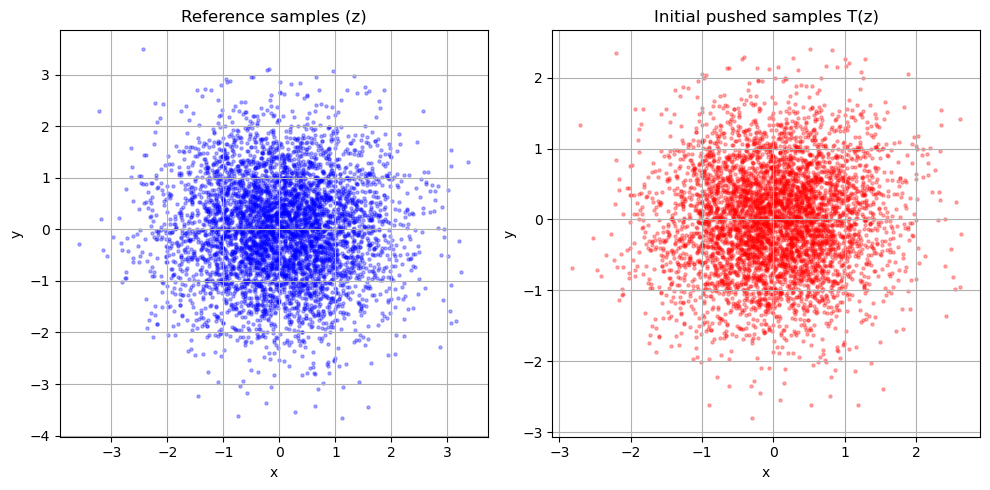

In [9]:
# Generate reference samples
key = jax.random.PRNGKey(1234)
n_samples = 5_000

key, subkey = jax.random.split(key)
z_samples = jax.random.normal(subkey, (n_samples, dim))

# Visualize initial samples
y_init = parametric_model_inna(samples=z_samples, params=init_params)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.scatter(z_samples[:, 0], z_samples[:, 1], c='blue', alpha=0.3, s=5)
plt.title('Reference samples (z)')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.scatter(y_init[:, 0], y_init[:, 1], c='red', alpha=0.3, s=5)
plt.title('Initial pushed samples T(z)')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)

plt.tight_layout()
plt.show()

INNA Flow Progress:   0%|          | 0/60 [00:00<?, ?it/s]

INNA Flow Progress:  42%|████▏     | 25/60 [00:47<00:55,  1.57s/it, Energy=0.056449, ||ψ||=0.00e+00, ||∇F||_G=1.15e+00]

Iter  25: Energy = 0.056449, ||∇F||_G = 1.15e+00, ||ψ|| = 0.00e+00


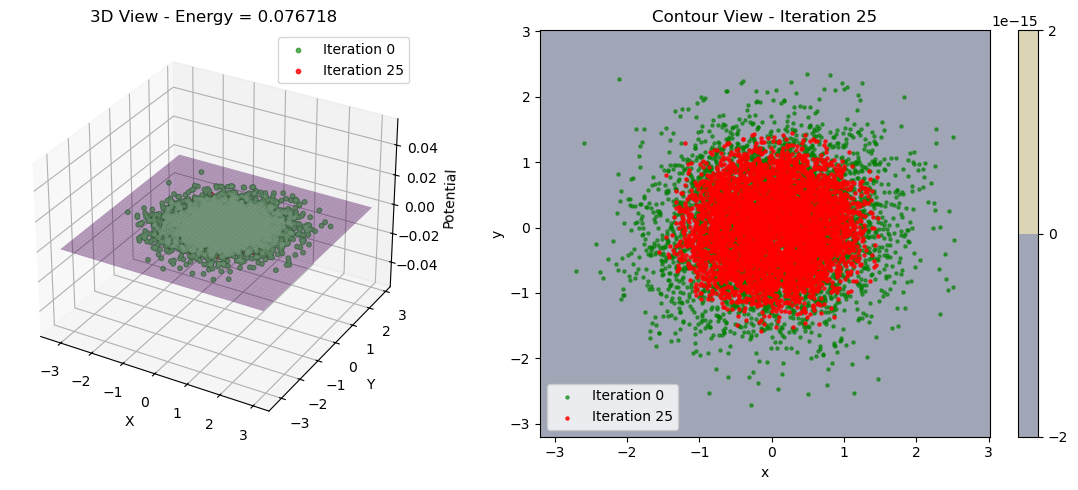

INNA Flow Progress:  83%|████████▎ | 50/60 [01:28<00:16,  1.64s/it, Energy=-0.027918, ||ψ||=0.00e+00, ||∇F||_G=6.19e-01]

Iter  50: Energy = -0.027918, ||∇F||_G = 6.19e-01, ||ψ|| = 0.00e+00


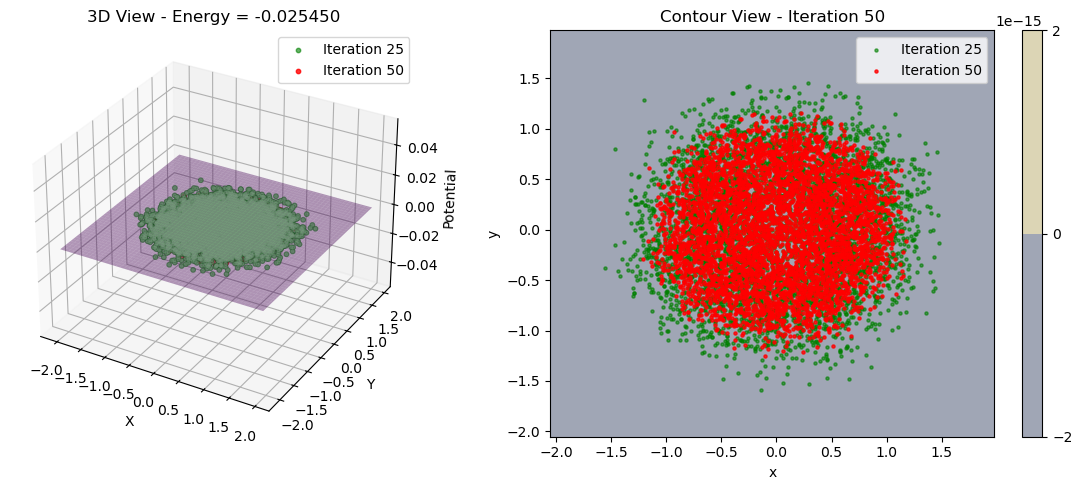

INNA Flow Progress:  98%|█████████▊| 59/60 [01:43<00:01,  1.60s/it, Energy=-0.042694, ||ψ||=0.00e+00, ||∇F||_G=5.00e-01]

Iter  59: Energy = -0.042694, ||∇F||_G = 5.00e-01, ||ψ|| = 0.00e+00


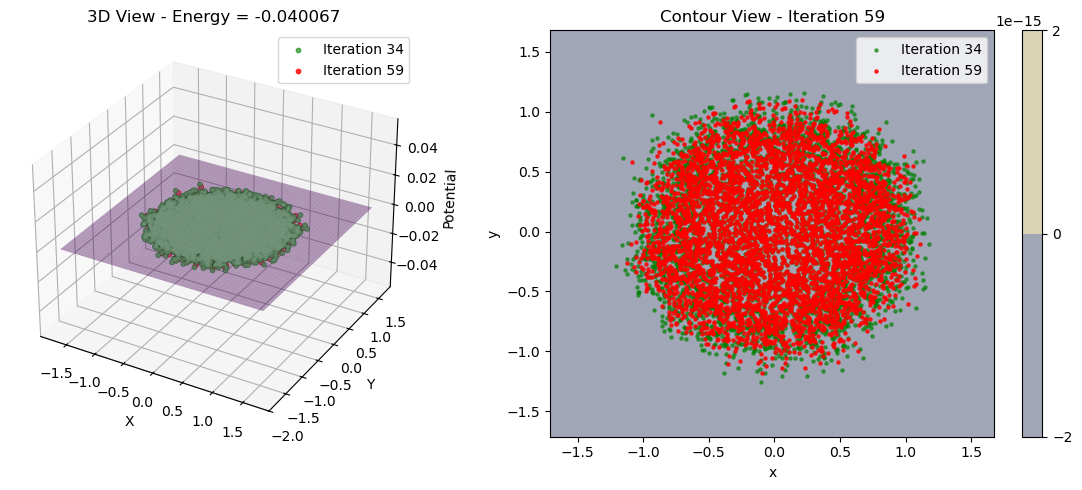

INNA Flow Progress: 100%|██████████| 60/60 [01:45<00:00,  1.75s/it, Energy=-0.042694, ||ψ||=0.00e+00, ||∇F||_G=5.00e-01]


=== INNA Integration Complete ===
Total iterations:    60
Initial energy:      0.833292
Final energy:        -0.040067
Total decrease:      0.873359
Reduction ratio:     -0.0481
Final ||ψ||:         0.000000
Final ||θ||:         4.279937


In [10]:
# Run INNA flow
inna_results = run_inna_flow(
    parametric_model_inna,
    z_samples,
    G_mat_inna,
    potential,
    N_samples=n_samples,
    gamma=gamma,
    a=a,
    b=b,
    beta=beta,
    solver=solver,
    max_iterations=max_iterations,
    tolerance=tolerance,
    regularization=regularization,
    progress_every=25,
    plot_intermediate=True,
)

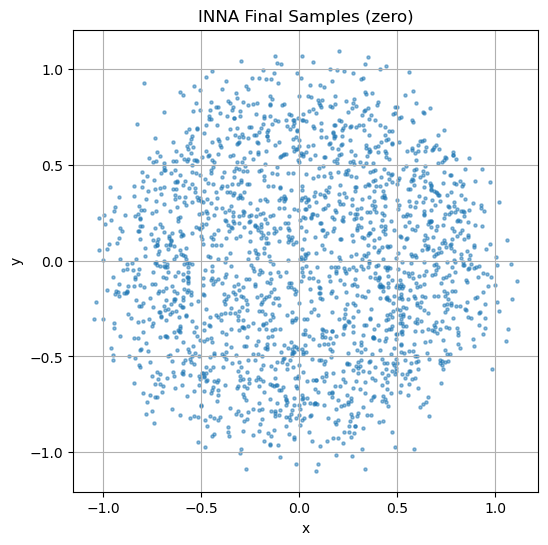

In [8]:
# Plot final INNA samples
_, inna_params = nnx.split(inna_results["final_parametric_model"])
samples_inna = parametric_model_inna(samples=z_samples, params=inna_params)

plt.figure(figsize=(6, 6))
plt.scatter(samples_inna[:, 0], samples_inna[:, 1], alpha=0.5, s=5)
plt.xlabel('x')
plt.ylabel('y')
plt.title(f'INNA Final Samples ({FUNCTIONAL_NAME})')
plt.grid(True)
plt.show()

## Gradient Flow (for comparison)

Gradient Flow Progress:   0%|          | 0/60 [00:00<?, ?it/s]

Gradient Flow Progress:  42%|████▏     | 25/60 [01:21<01:43,  2.95s/it, Energy=-50.173912, Linear=-41.075356, Internal=-9.098556, Interaction=0.000000]

Iter  25: Energy = -50.173912, Grad norm: 7.30e+02


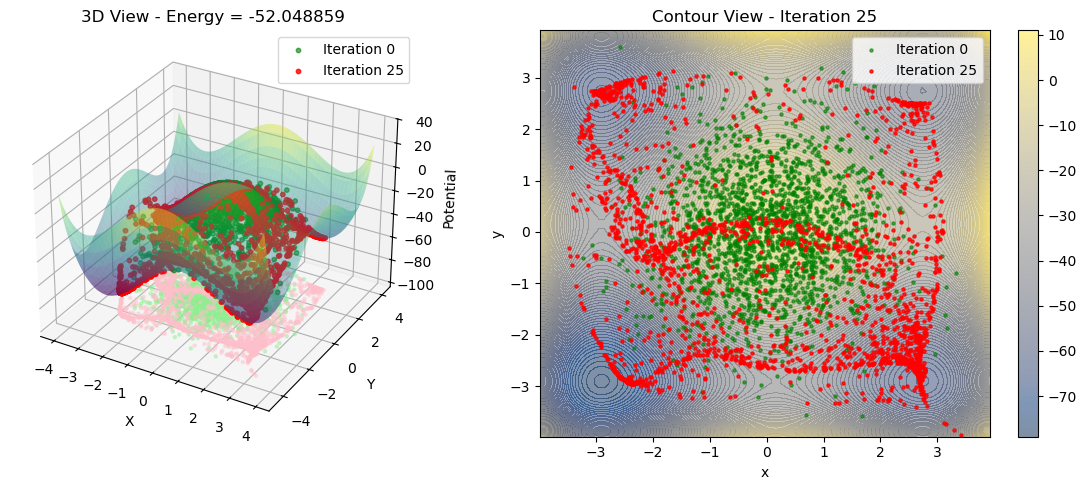

Gradient Flow Progress:  83%|████████▎ | 50/60 [02:38<00:29,  2.97s/it, Energy=-65.473976, Linear=-57.180969, Internal=-8.293008, Interaction=0.000000]

Iter  50: Energy = -65.473976, Grad norm: 8.67e+02


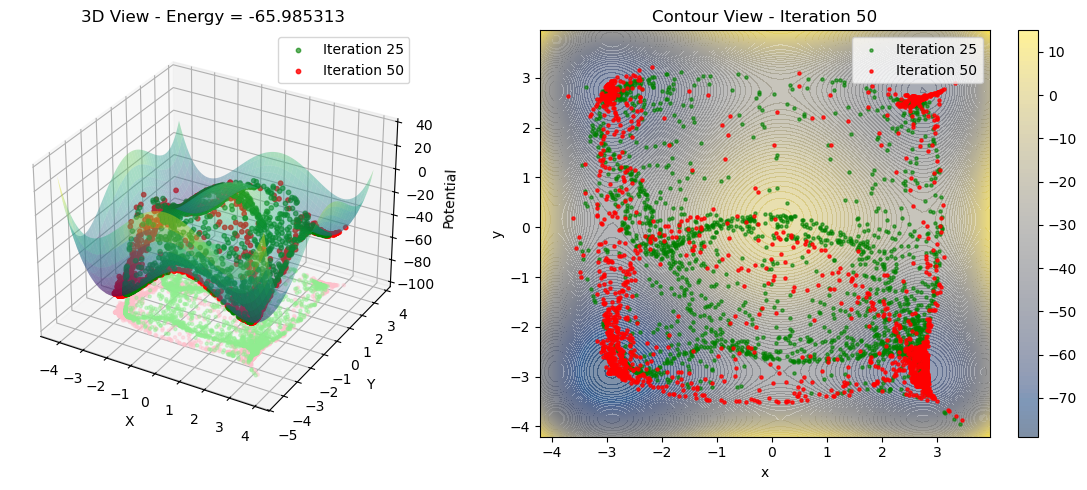

Gradient Flow Progress:  97%|█████████▋| 58/60 [03:03<00:05,  2.99s/it, Energy=-67.493767, Linear=-59.499924, Internal=-7.993840, Interaction=0.000000]

Iter  58: Energy = -67.493767, Grad norm: 8.45e+02


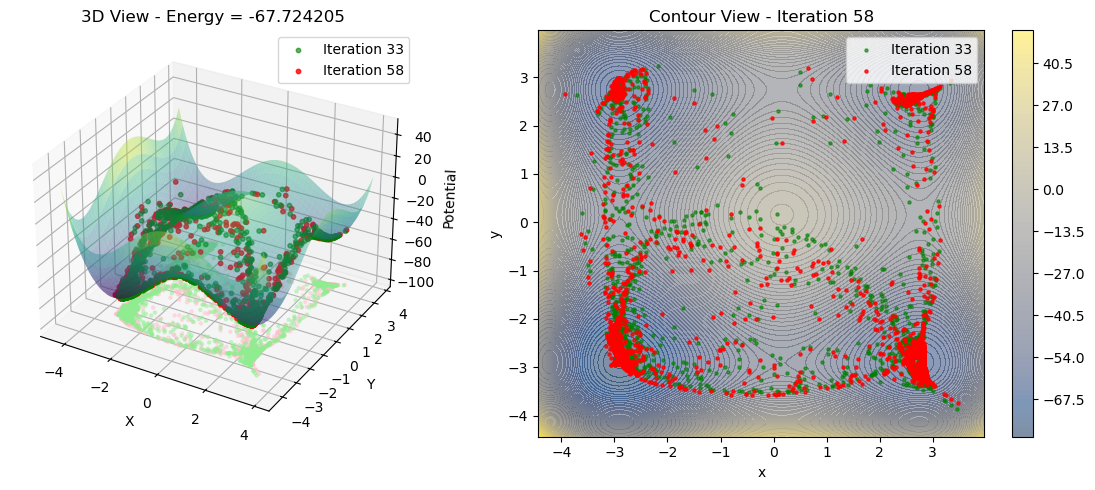

Gradient Flow Progress: 100%|██████████| 60/60 [03:07<00:00,  3.13s/it, Energy=-68.256119, Linear=-60.217487, Internal=-8.038635, Interaction=0.000000]


=== Integration Complete ===
Total iterations:    60
Initial energy:      -16.436056
Final energy:        -67.852936
Total decrease:      51.416878
Reduction ratio:     4.1283
Final param norm:    16.322107


In [ ]:
# Create fresh model for gradient flow
parametric_model_gf = ParametricModel(
    parametric_map=type_net,
    rhs_model=rhs_net,
    architecture=arch ,
    activation_fn=activation_fn,
    time_dependent=time_dependent,
    solver=solver_node,
    dt0=dt0,
    ref_density=ref_density,
    scale_factor=scale_factor,
)

G_mat_gf = G_matrix(parametric_model_gf)

# Run gradient flow with same step size for fair comparison
gf_results = run_gradient_flow(
    parametric_model_gf,
    z_samples,
    G_mat_gf,
    potential,
    N_samples=n_samples,
    h=gamma,  # Same step size as INNA
    solver=solver,
    max_iterations=max_iterations,
    tolerance=tolerance,
    regularization=regularization,
    progress_every=25,
)

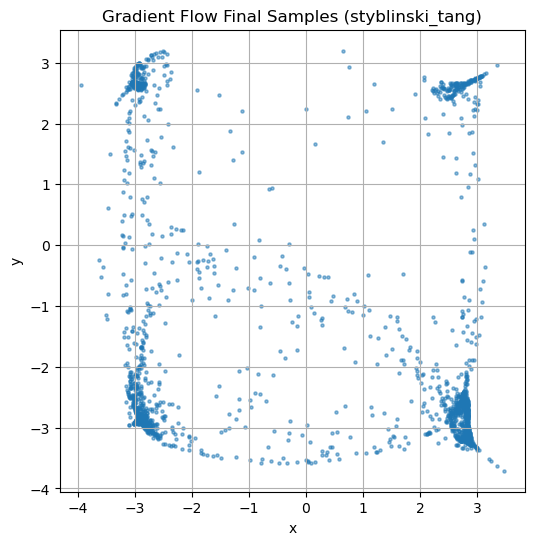

In [ ]:
# Plot final gradient flow samples
_, gf_params = nnx.split(gf_results["final_parametric_model"])
samples_gf = parametric_model_gf(samples=z_samples, params=gf_params)

plt.figure(figsize=(6, 6))
plt.scatter(samples_gf[:, 0], samples_gf[:, 1], alpha=0.5, s=5)
plt.xlabel('x')
plt.ylabel('y')
plt.title(f'Gradient Flow Final Samples ({FUNCTIONAL_NAME})')
plt.grid(True)
plt.show()

## Comparison: INNA vs Gradient Flow

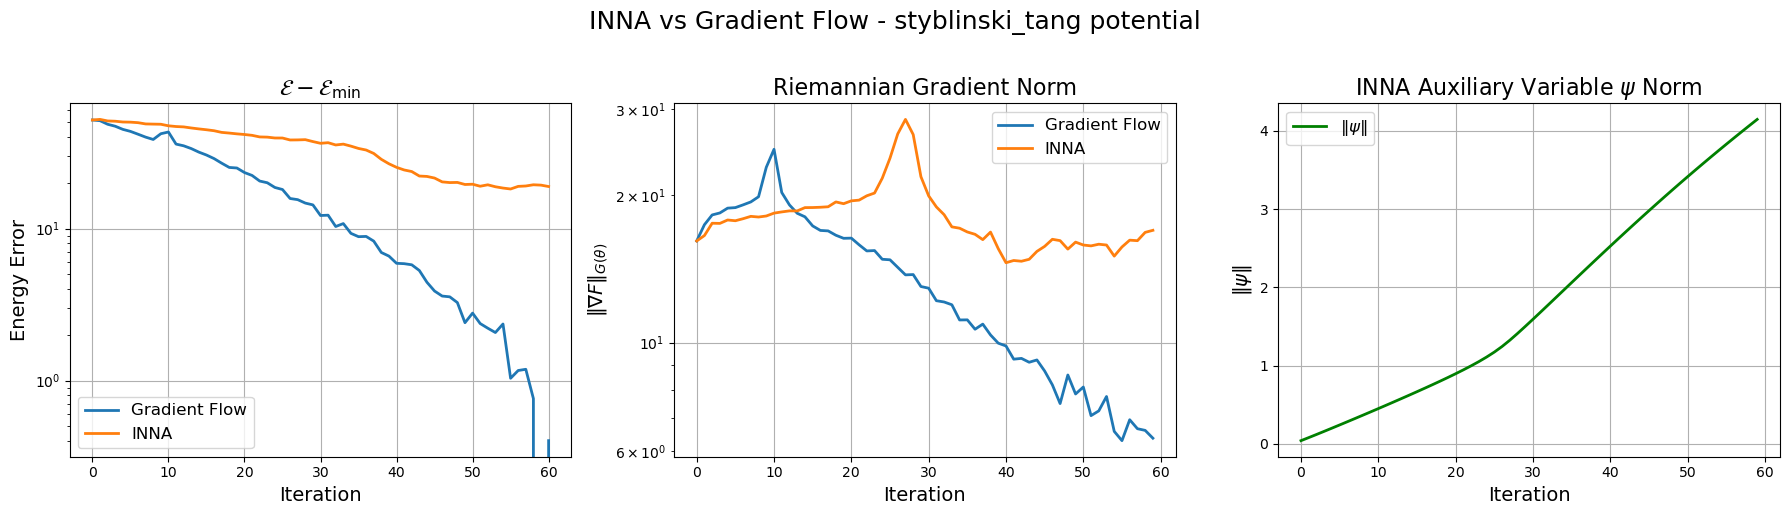

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# Energy comparison
ax = axs[0]
e_gf = jnp.array(gf_results["energy_history"])
e_inna = jnp.array(inna_results["energy_history"])
e_min = jnp.min(jnp.concatenate((e_gf, e_inna))) - 1e-10
e_gf_shifted = e_gf - e_min
e_inna_shifted = e_inna - e_min

ax.plot(e_gf_shifted, label='Gradient Flow', linewidth=2)
ax.plot(e_inna_shifted, label='INNA', linewidth=2)
ax.set_yscale("log")
ax.set_xlabel('Iteration', fontsize=14)
ax.set_ylabel('Energy Error', fontsize=14)
ax.set_title(r'$\mathcal{E} - \mathcal{E}_{\text{min}}$', fontsize=16)
ax.grid(True)
ax.legend(fontsize=12)

# Riemannian gradient norm comparison
ax = axs[1]
ax.plot(gf_results['riemann_grad_norm_history'], label='Gradient Flow', linewidth=2)
ax.plot(inna_results['riemann_grad_norm_history'], label='INNA', linewidth=2)
ax.set_yscale('log')
ax.set_xlabel('Iteration', fontsize=14)
ax.set_ylabel(r'$\| \nabla F\|_{G(\theta)}$', fontsize=14)
ax.set_title('Riemannian Gradient Norm', fontsize=16)
ax.grid(True)
ax.legend(fontsize=12)

# INNA-specific: psi norm evolution
ax = axs[2]
ax.plot(inna_results['psi_norm_history'], label=r'$\|\psi\|$', linewidth=2, color='green')
ax.set_xlabel('Iteration', fontsize=14)
ax.set_ylabel(r'$\|\psi\|$', fontsize=14)
ax.set_title(r'INNA Auxiliary Variable $\psi$ Norm', fontsize=16)
ax.grid(True)
ax.legend(fontsize=12)

fig.suptitle(f'INNA vs Gradient Flow - {FUNCTIONAL_NAME} potential', fontsize=18, y=1.02)
fig.tight_layout()
plt.show()

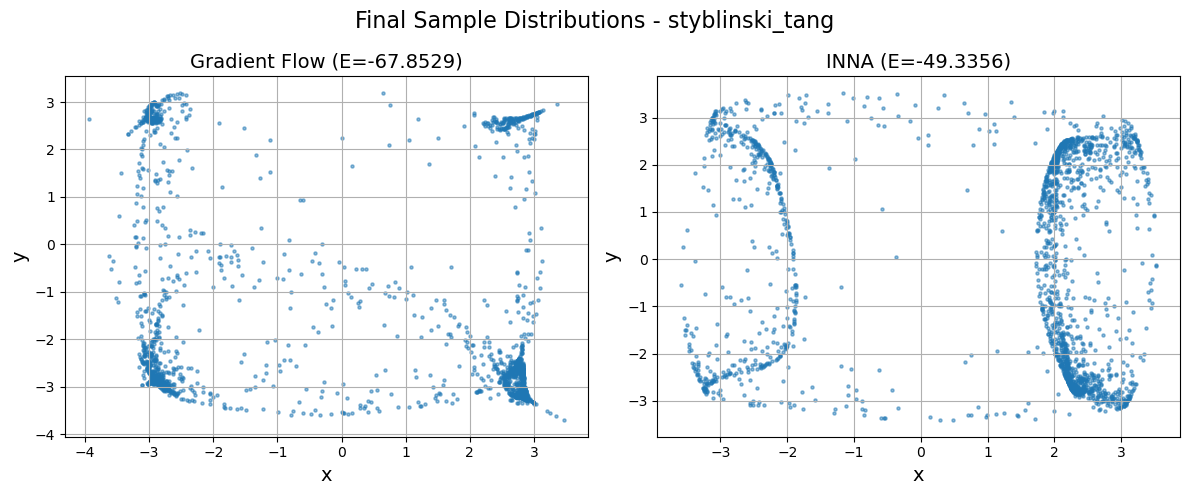

In [ ]:
# Side-by-side sample comparison
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

ax = axs[0]
ax.scatter(samples_gf[:, 0], samples_gf[:, 1], alpha=0.5, s=5)
ax.set_xlabel('x', fontsize=14)
ax.set_ylabel('y', fontsize=14)
ax.set_title(f'Gradient Flow (E={gf_results["energy_history"][-1]:.4f})', fontsize=14)
ax.grid(True)

ax = axs[1]
ax.scatter(samples_inna[:, 0], samples_inna[:, 1], alpha=0.5, s=5)
ax.set_xlabel('x', fontsize=14)
ax.set_ylabel('y', fontsize=14)
ax.set_title(f'INNA (E={inna_results["energy_history"][-1]:.4f})', fontsize=14)
ax.grid(True)

fig.suptitle(f'Final Sample Distributions - {FUNCTIONAL_NAME}', fontsize=16)
fig.tight_layout()
plt.show()

In [71]:
# Summary statistics
print("=" * 50)
print(f"SUMMARY - {FUNCTIONAL_NAME} potential")
print("=" * 50)
print(f"\nGradient Flow:")
print(f"  Final Energy: {gf_results['energy_history'][-1]:.6f}")
print(f"  Iterations: {len(gf_results['energy_history'])-1}")
print(f"\nINNA (gamma={gamma}, a={a}, b={b}, beta={beta}):")
print(f"  Final Energy: {inna_results['energy_history'][-1]:.6f}")
print(f"  Iterations: {len(inna_results['energy_history'])-1}")
print(f"  Final ||psi||: {inna_results['psi_norm_history'][-1]:.6f}")

SUMMARY - styblinski_tang potential

Gradient Flow:
  Final Energy: -67.852936
  Iterations: 60

INNA (gamma=0.005, a=-2.0, b=4.0, beta=0.25):
  Final Energy: -49.335606
  Iterations: 60
  Final ||psi||: 4.146801
